## Testing Checkerboard and Alpha Linear Fit Algorithms on Simulation Data (15th Dec 2025)
Having verified both linear fitting algorithms work on data with known lifetimes, here I seek to examine how these alogrithms handle simulation data. First, I'll check the algorithm for varying $\alpha$ values before then moving on to the checkerboard algorithm. I'll then examine how both cases deal with noise applied to the simulated data.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.optimize as so
import scipy.signal as ss
import matplotlib.patches as patches
import matplotlib.lines as mlines
import torch 
try:
    import pySIMsalabim as sim
except ImportError: # add parent directory to sys.path if pySIMsalabim is not installed
    sys.path.append('../../../..')
    import pySIMsalabim as sim
from pySIMsalabim.experiments import impls
from pySIMsalabim.aux_funcs import time_domain_DRT as drt

In [2]:
# Path to data
path = '/home/josh-edmundson/Documents/SIMsalabim-installs/pySIMsalabim/Notebooks/Projects/Den RT/DRT IS Inductive Behaviour in Spectrum/tj.dat'

In [3]:
# Load Data
data = pd.read_csv(path, sep=r'\s+')

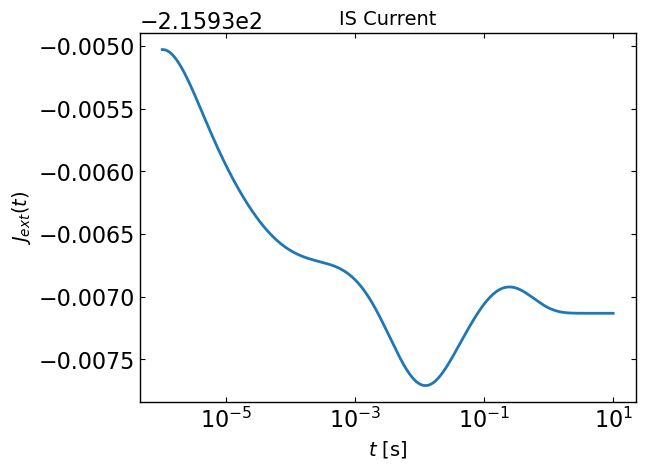

In [4]:
# Find where in the current density curve we see decay lifetimes 
start_index = 155
end_index = -1 #870
time = data['t'].iloc[start_index:end_index].values
current = data['Jext'].iloc[start_index:end_index].values

# Plot the Current Density
plt.plot(time, current)
plt.xscale('log')
plt.xlabel('$t$ [$\\text{s}$]')
plt.ylabel('$J_{ext}(t)$')
plt.title("IS Current")
plt.show()


In [5]:
# Define the tau grid to use for linear fits 

# Calculate the number of decades and points per decade (ppd) in the time array
time_decades = np.log10(time[-1]/time[0])
time_ppd = len(time) / time_decades

# Define the tau values as a relative multiple of ppd
relative_resolution = 1 
tau_values = np.geomspace(time[0], time[1], relative_resolution*len(time))

In [6]:
# Apply min-max scaling to the data 
current_scaled = (current - current.min())/(current.max() - current.min())

In [7]:
# Perform a linear alpha fit on this curve for 10 different alpha values
alpha_values = np.geomspace(1e-3, 1e1, 15)
alpha_fits = []

for i in range(len(alpha_values)):
    # Peform and save the fit
    fit = drt.fit_DRT_curve_linear_torch(time, current_scaled, time, alpha=alpha_values[i], max_iter=500)
    alpha_fits.append(fit)

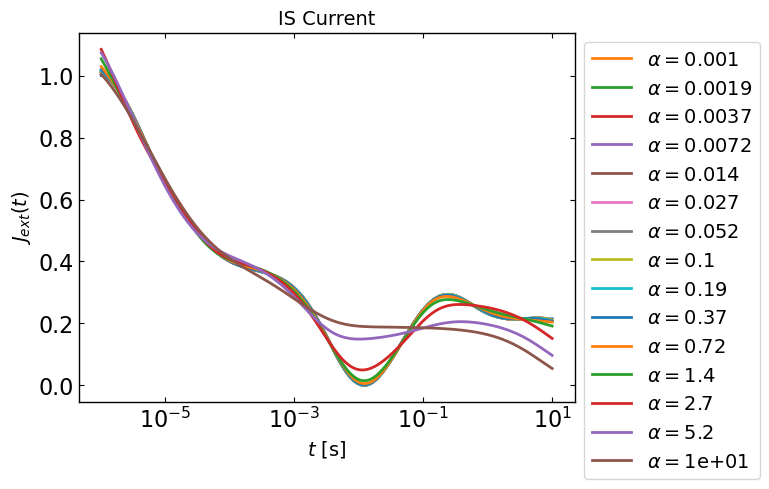

In [8]:
# Plot how the reconstructed DRT curves look compared to the original
plt.plot(time, current_scaled)

for i in range(len(alpha_values)):
    plt.plot(time, alpha_fits[i].DRT_curve, label=f'$\\alpha=${alpha_values[i]:.2}')

plt.xscale('log')
plt.xlabel('$t$ [$\\text{s}$]')
plt.ylabel('$J_{ext}(t)$')
plt.title("IS Current")
plt.legend(bbox_to_anchor=(1,1), loc="upper left")
plt.show()

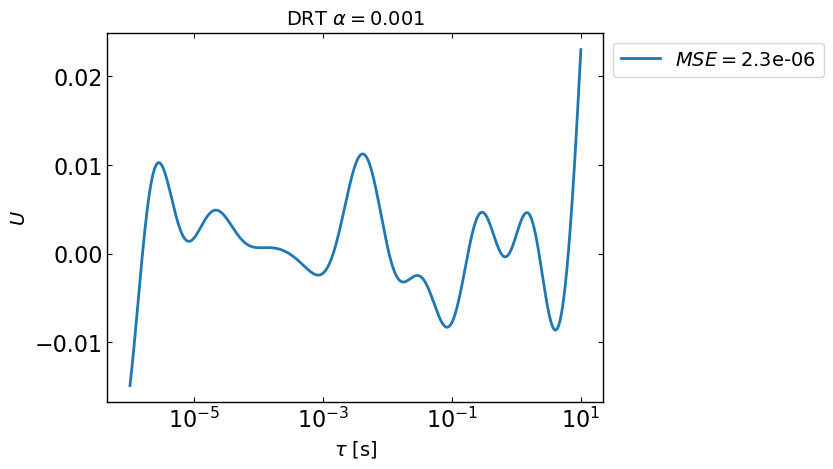

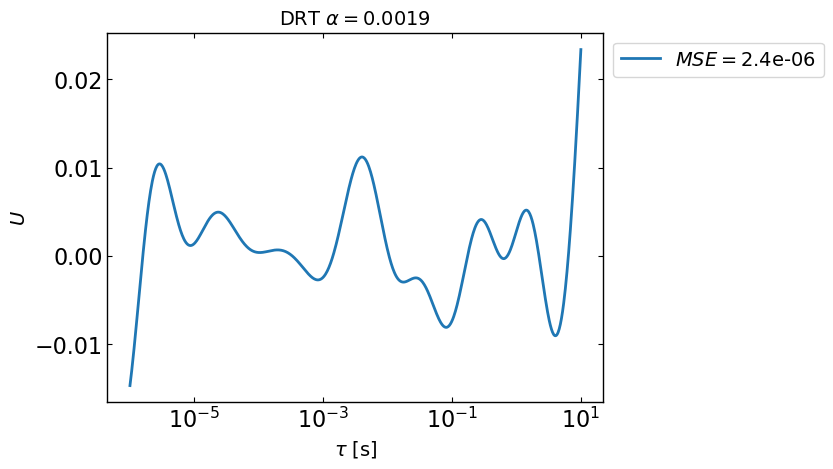

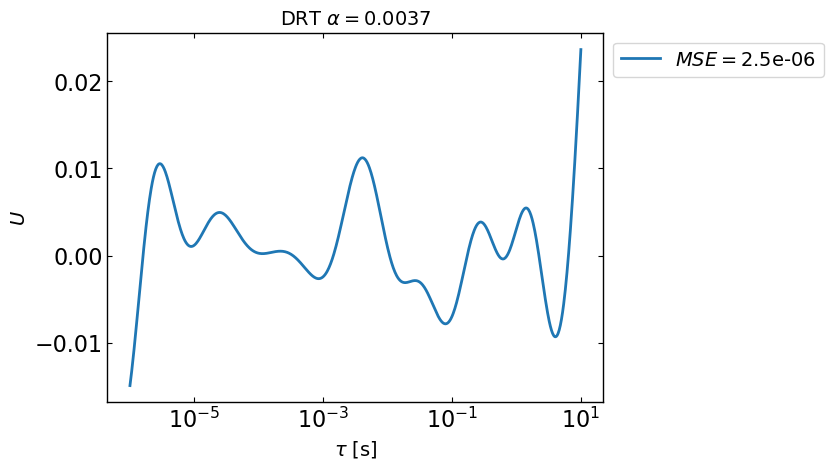

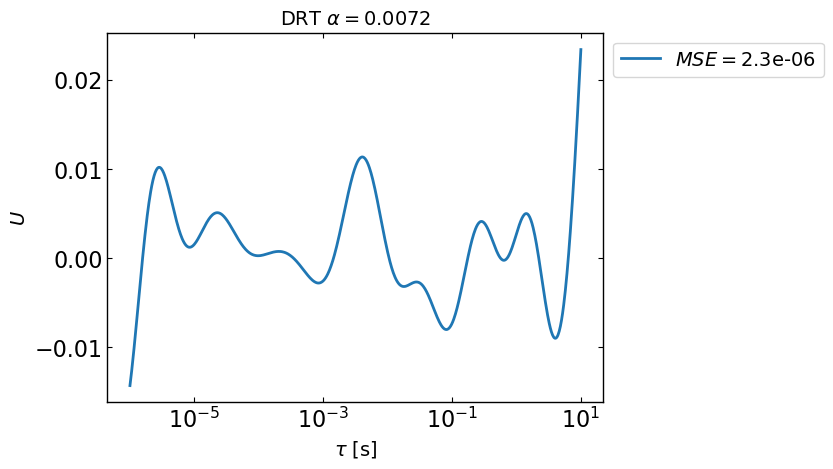

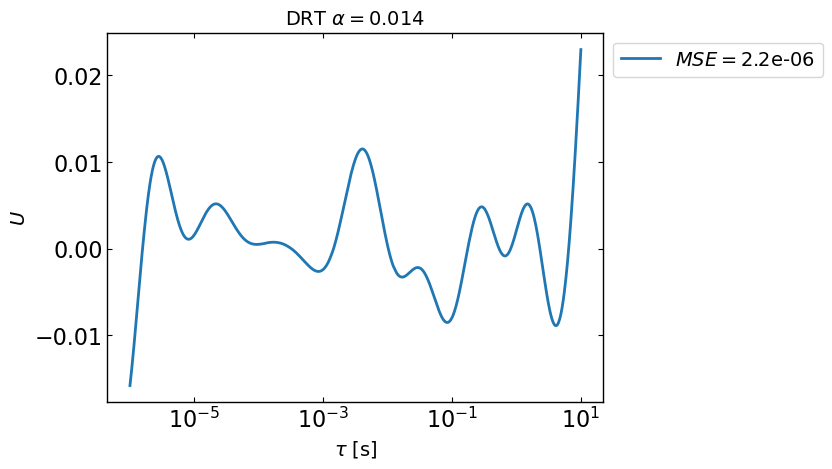

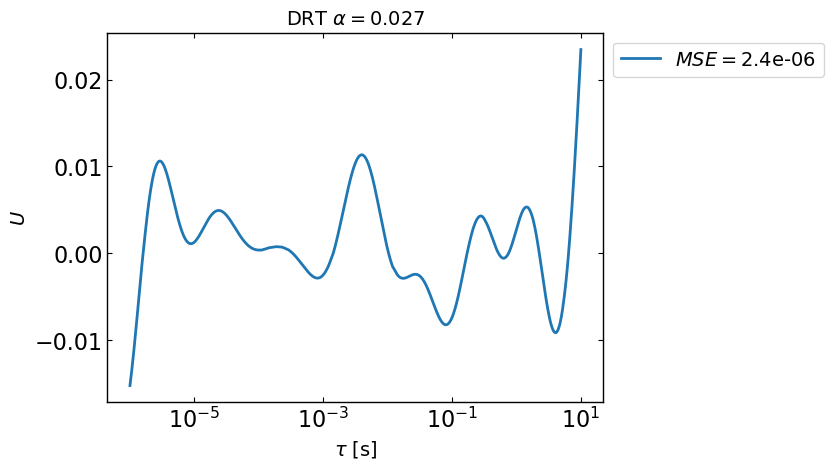

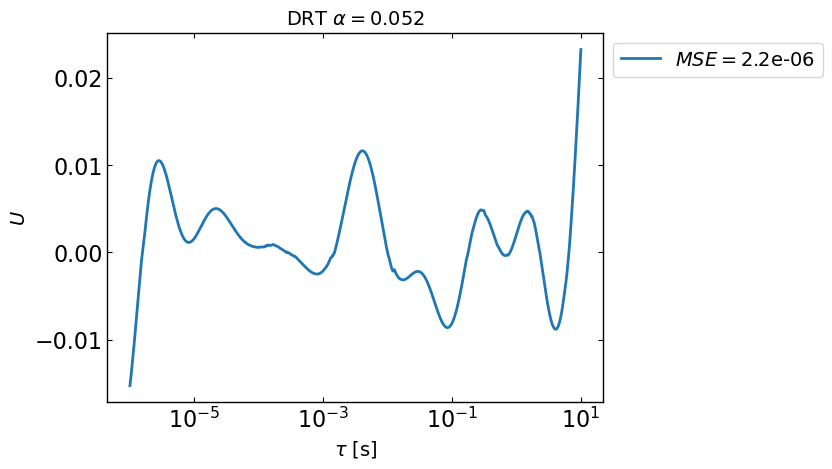

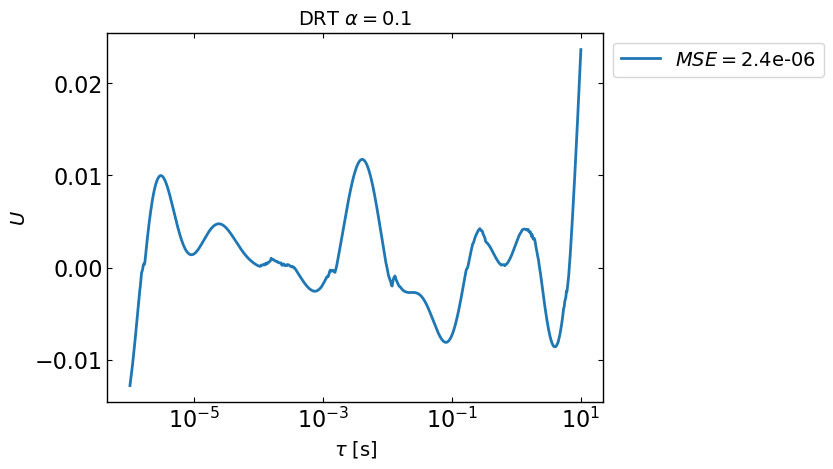

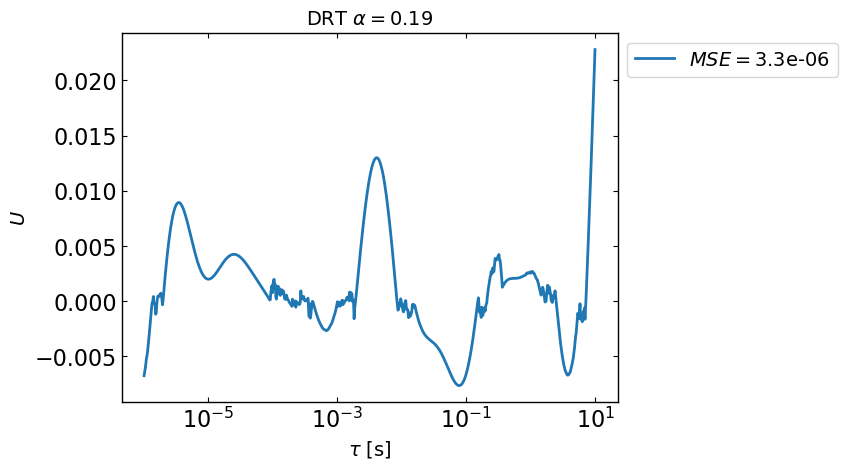

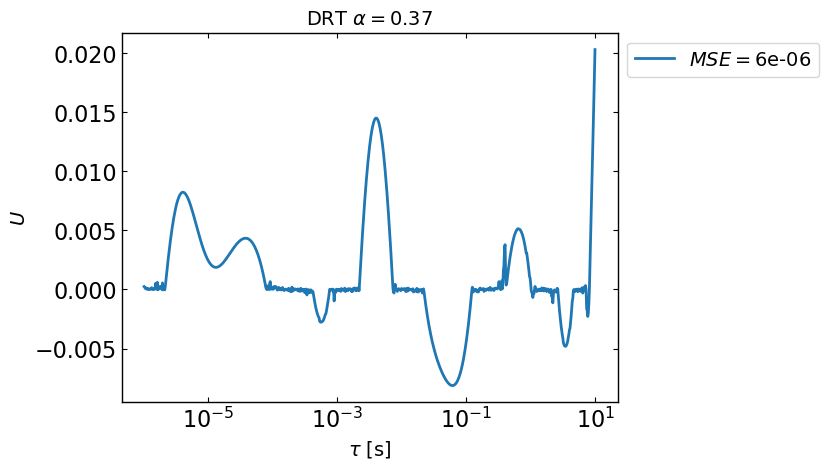

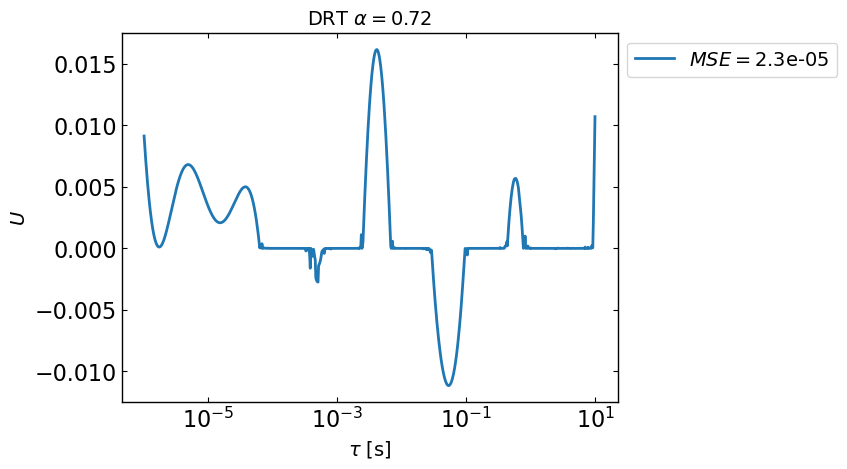

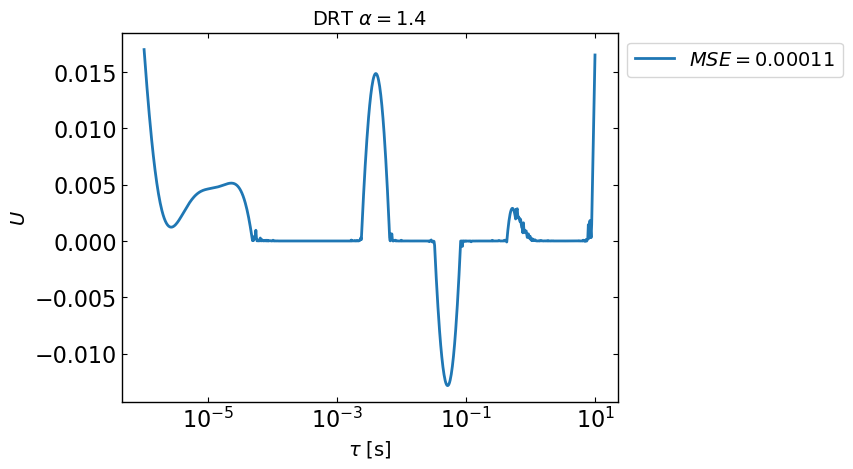

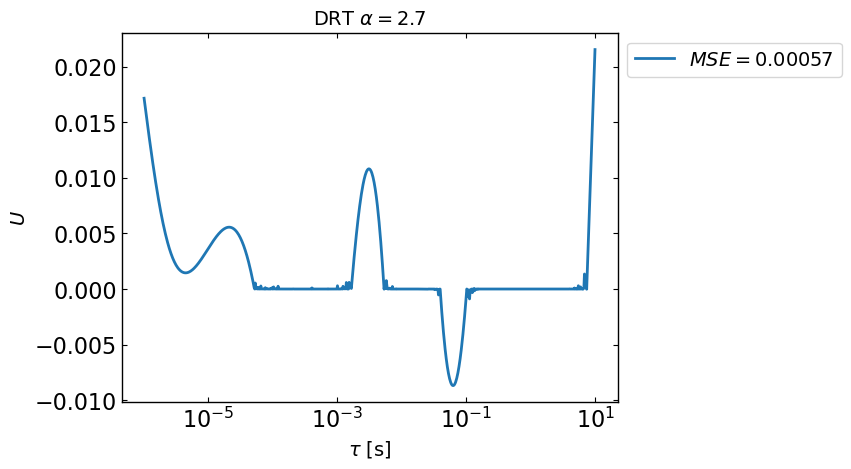

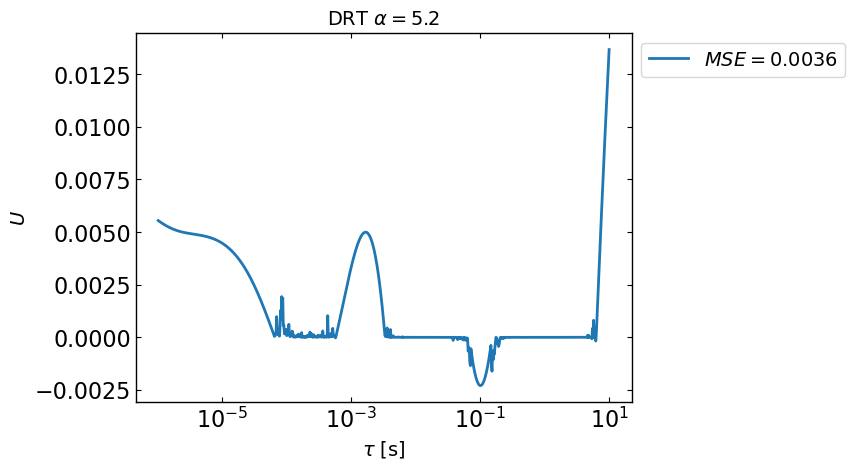

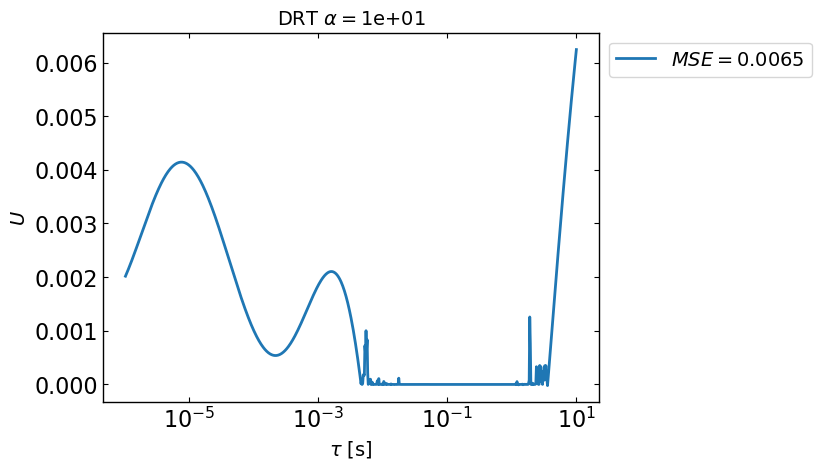

In [9]:
# Now plot the distribution of relaxation times for each
for i in range(len(alpha_values)):
    MSE = np.mean((current_scaled - alpha_fits[i].DRT_curve)**2)
    plt.plot(time, alpha_fits[i].U, label=f'$MSE=${MSE:.2}')
    plt.xscale('log')
    plt.xlabel('$\\tau$ [$\\text{s}$]')
    plt.ylabel('$U$')
    plt.title(f"DRT $\\alpha=${alpha_values[i]:.2}")
    plt.legend(bbox_to_anchor=(1,1), loc="upper left")
    plt.show()

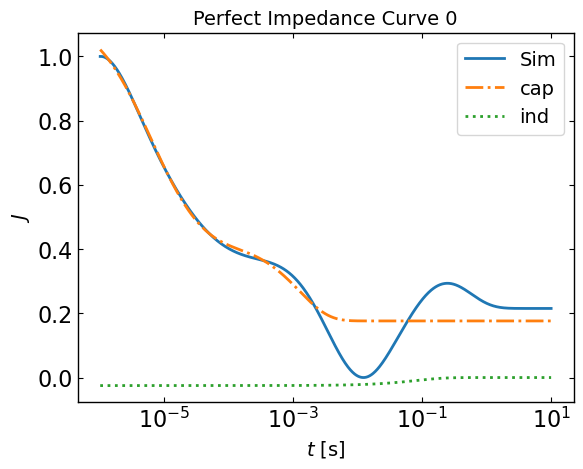

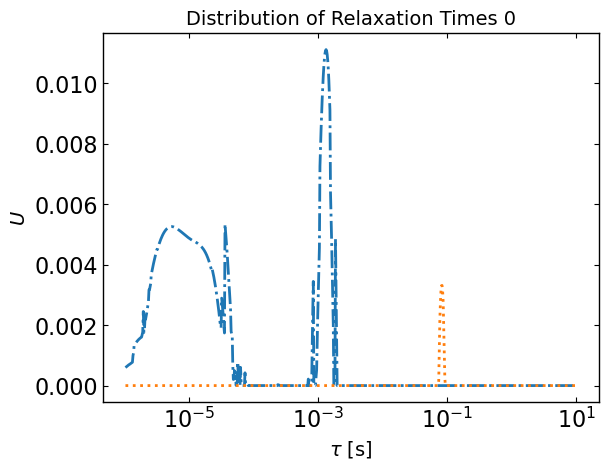

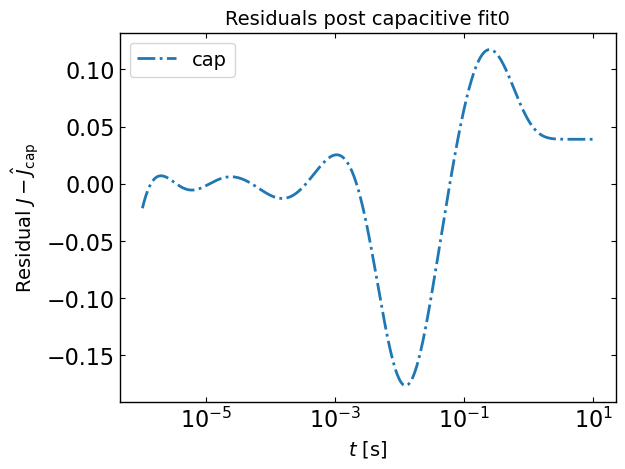

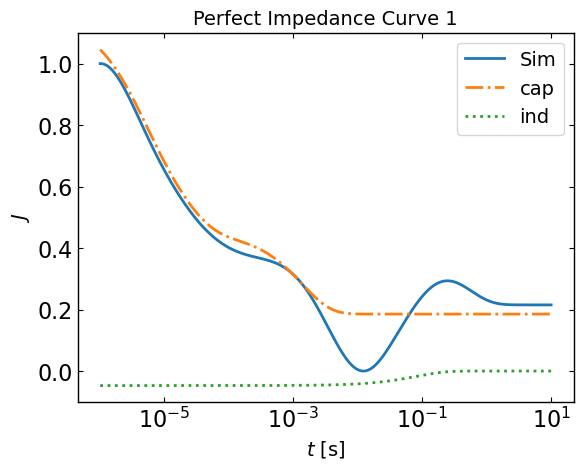

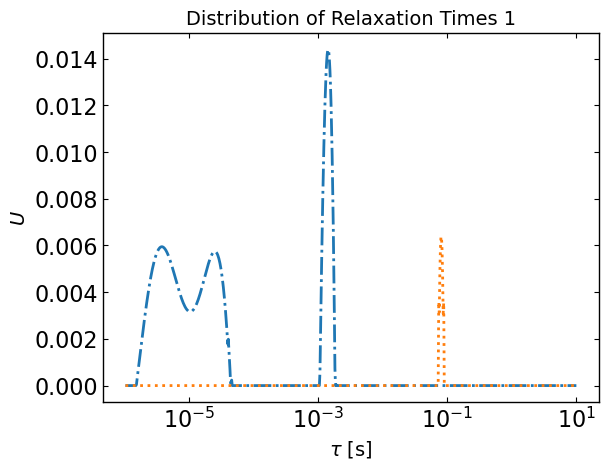

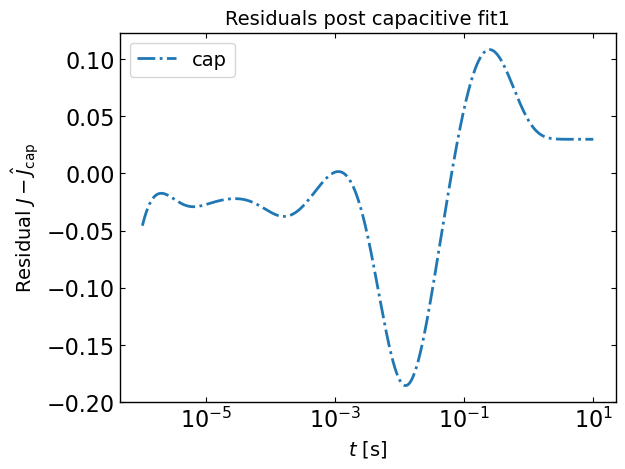

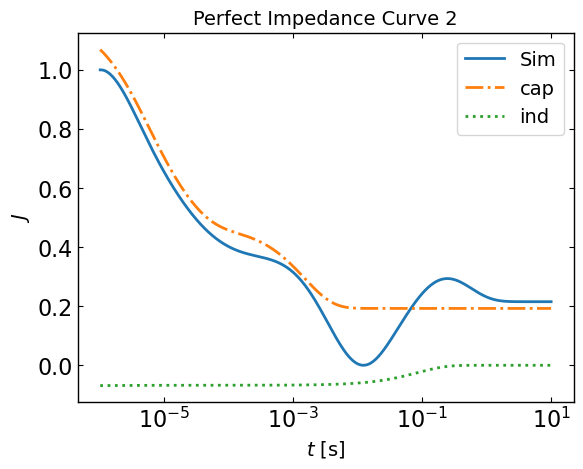

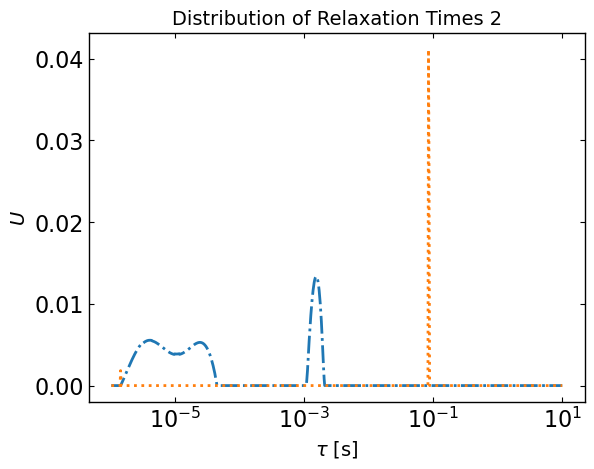

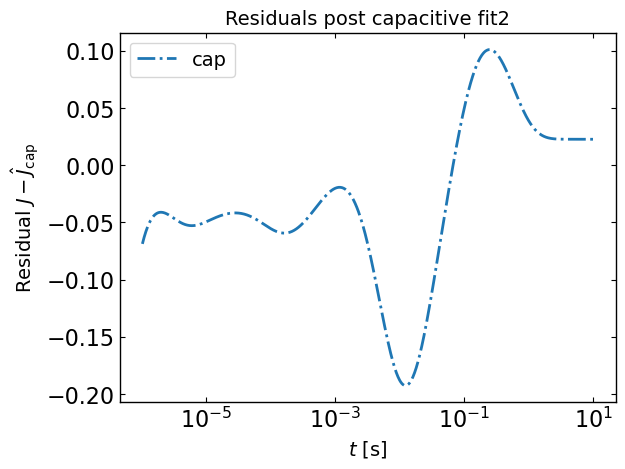

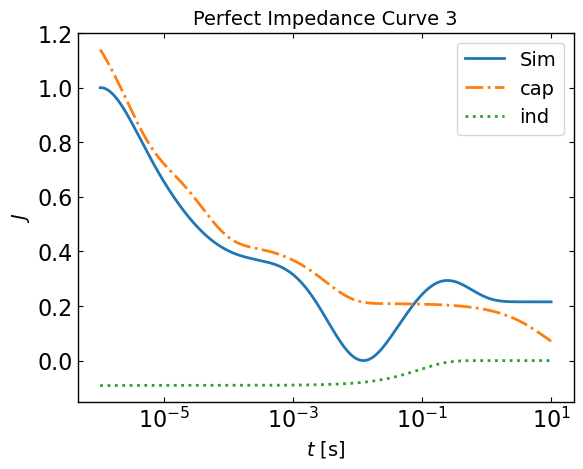

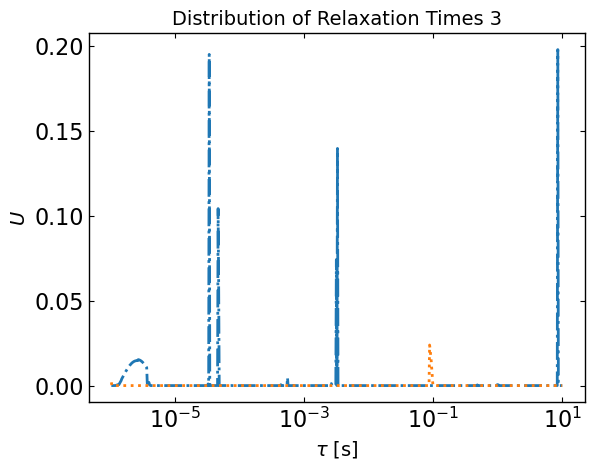

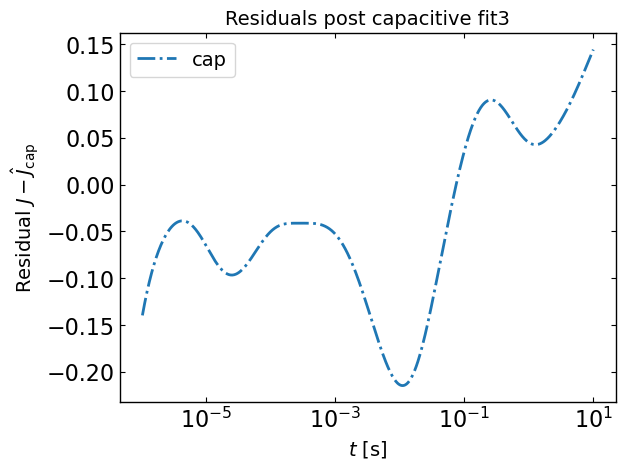

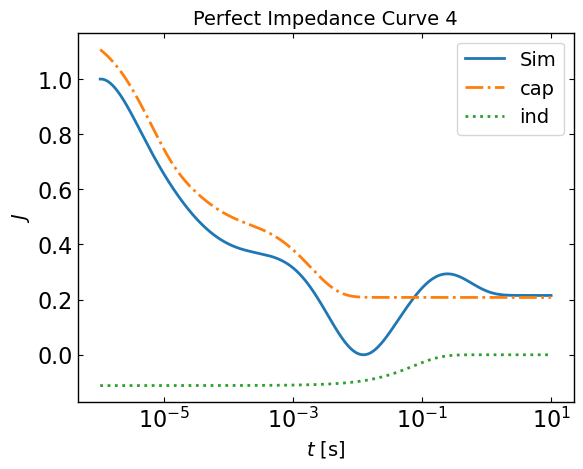

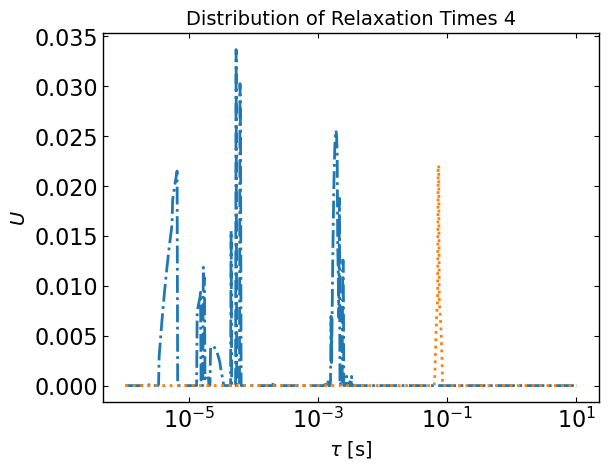

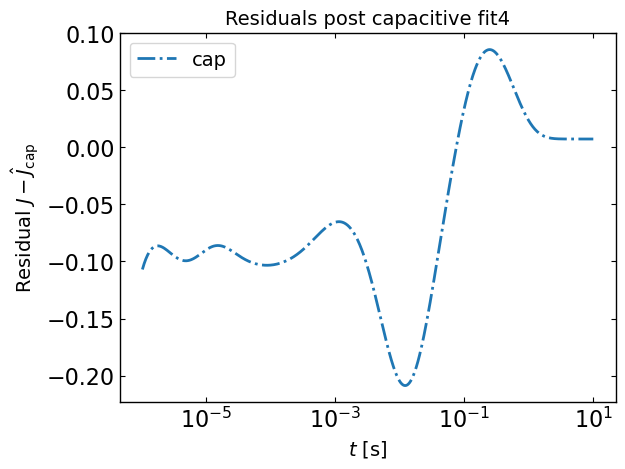

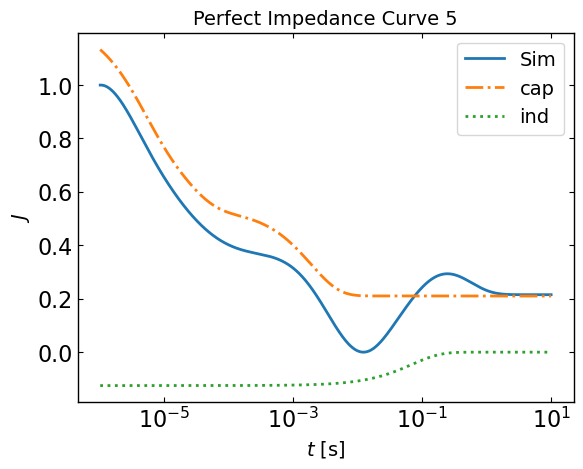

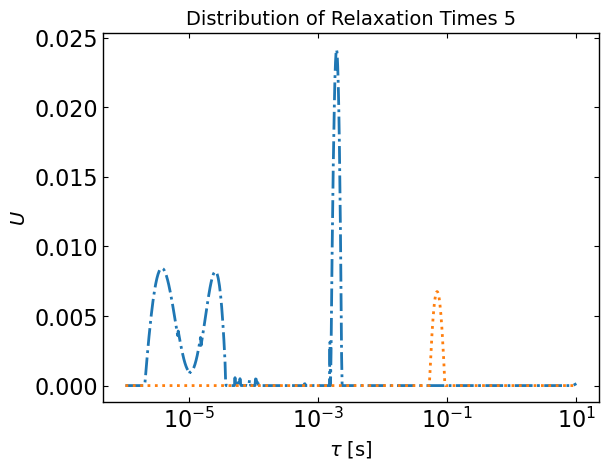

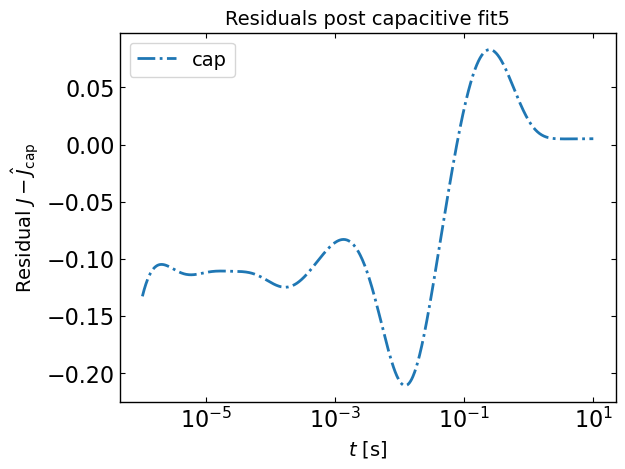

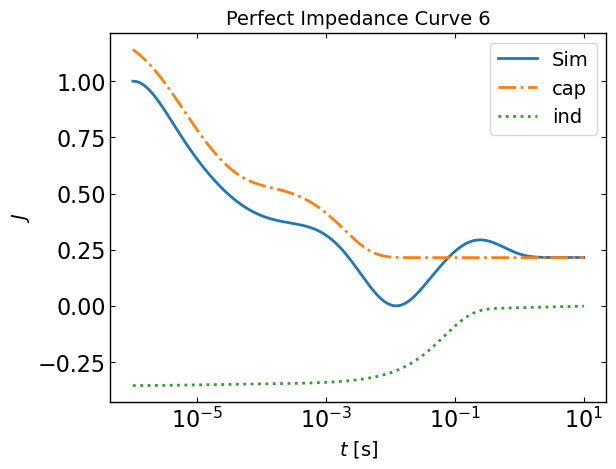

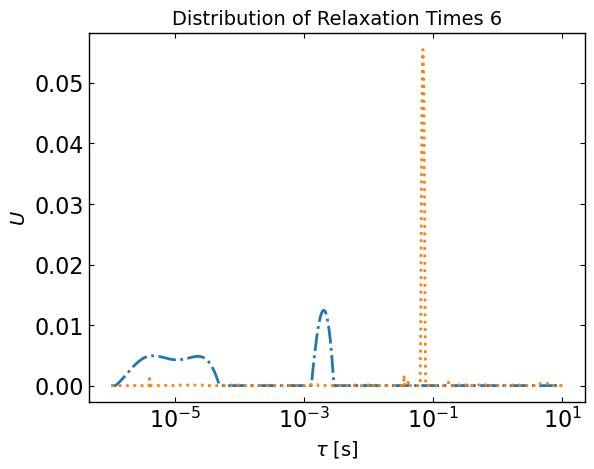

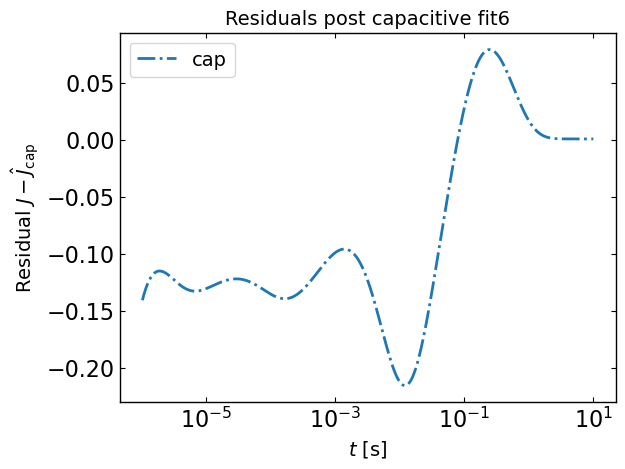

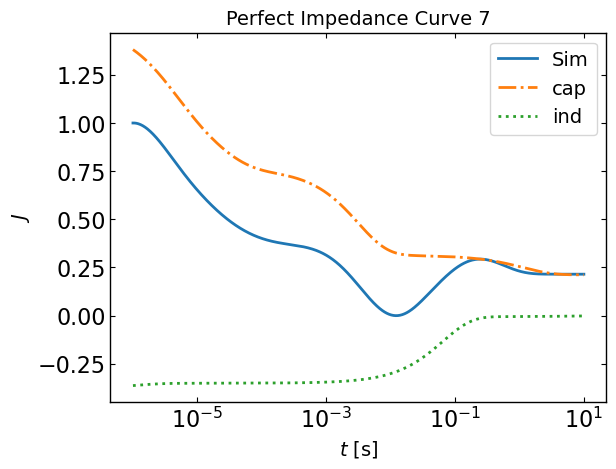

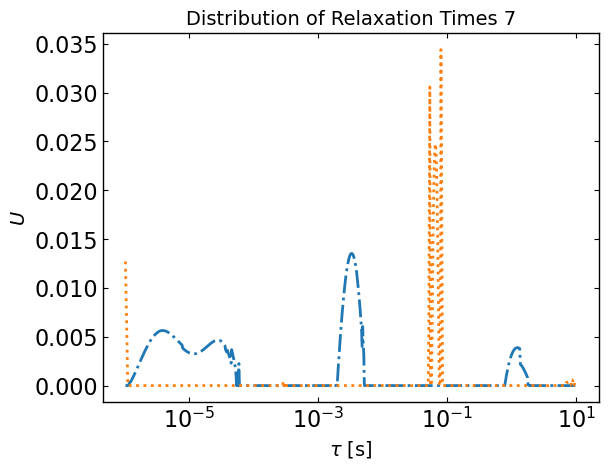

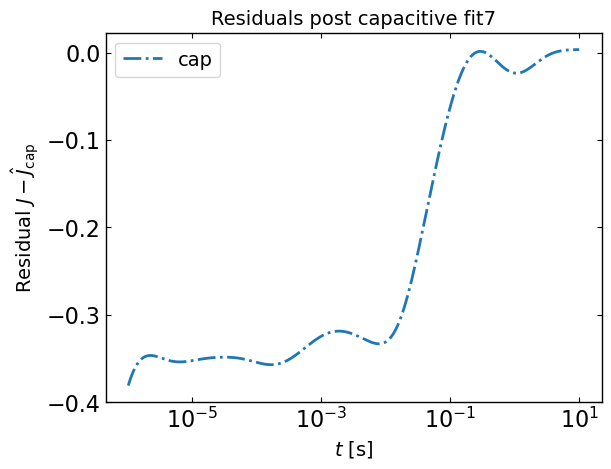

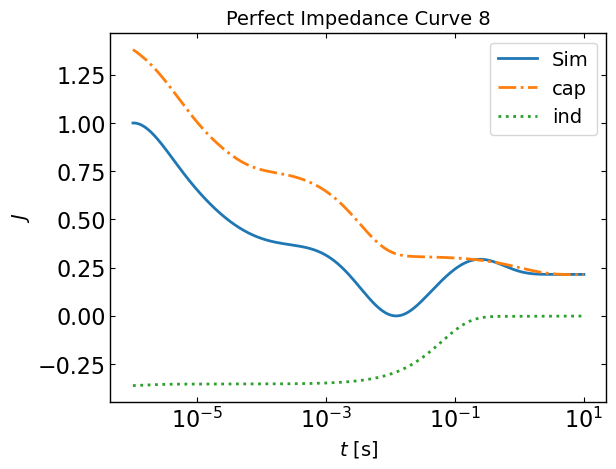

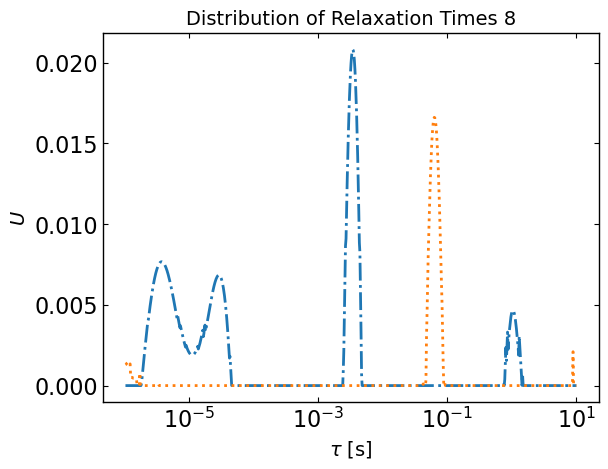

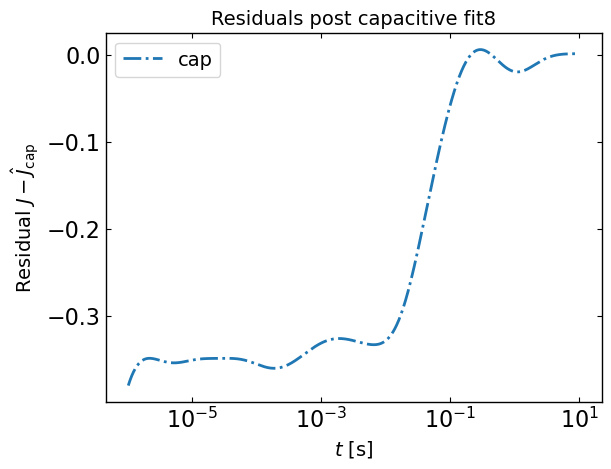

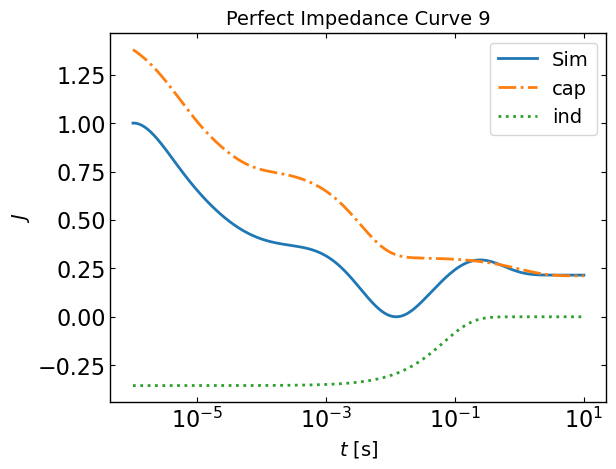

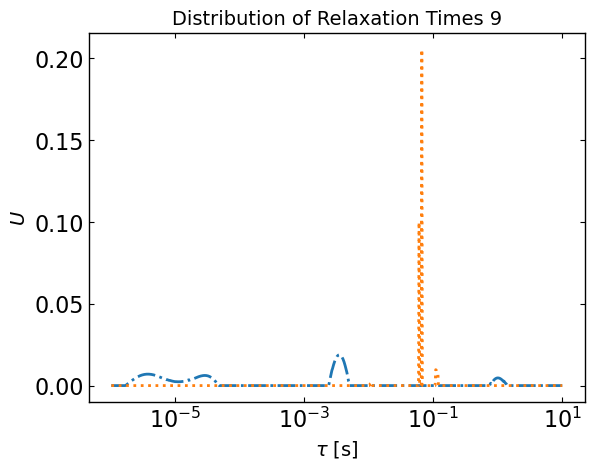

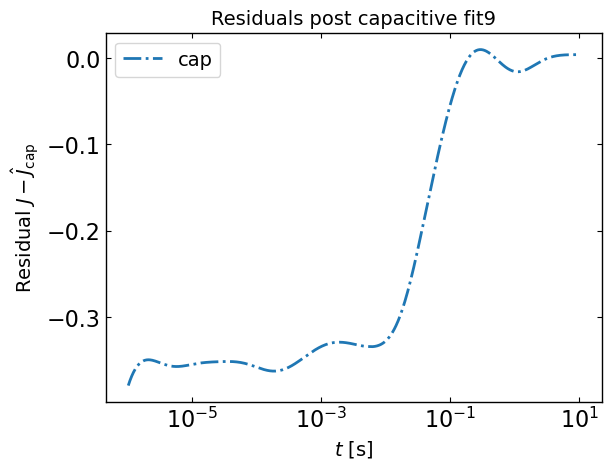

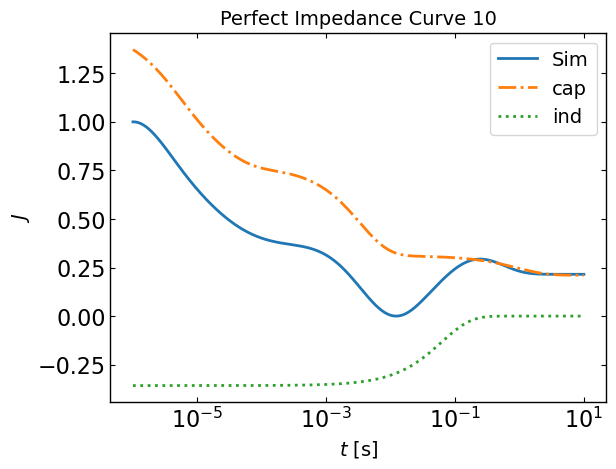

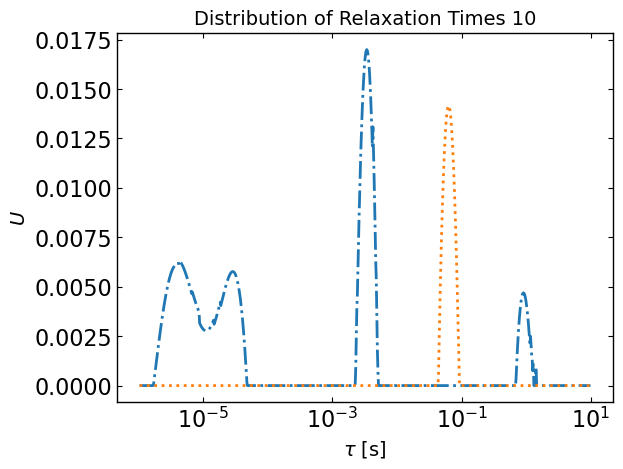

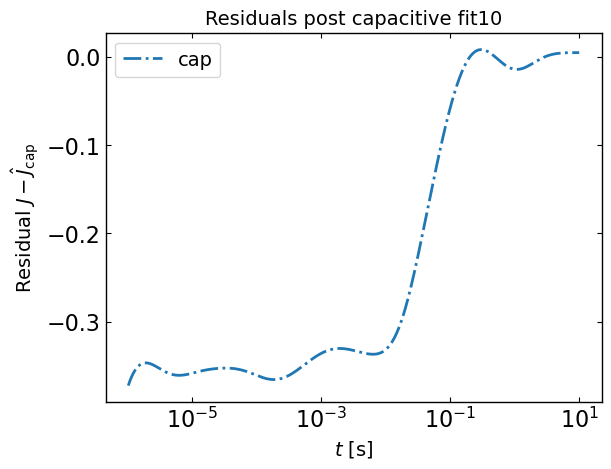

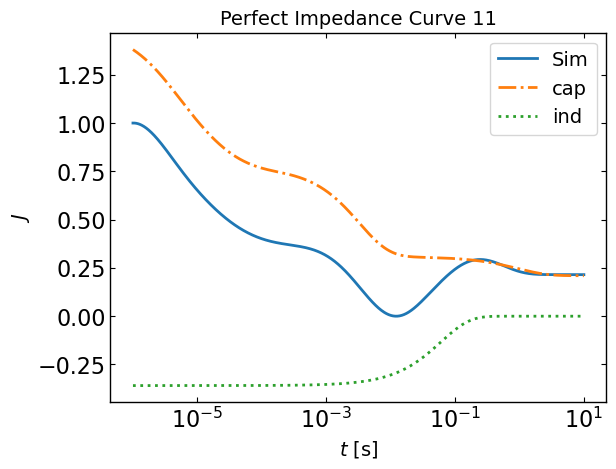

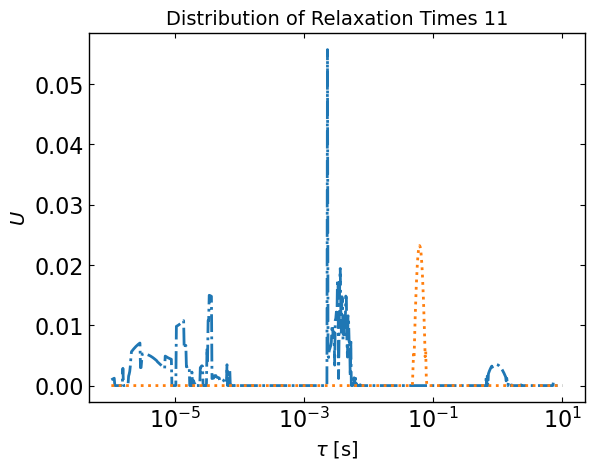

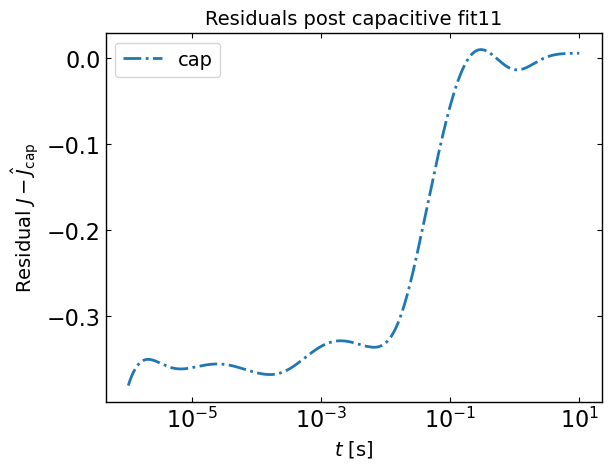

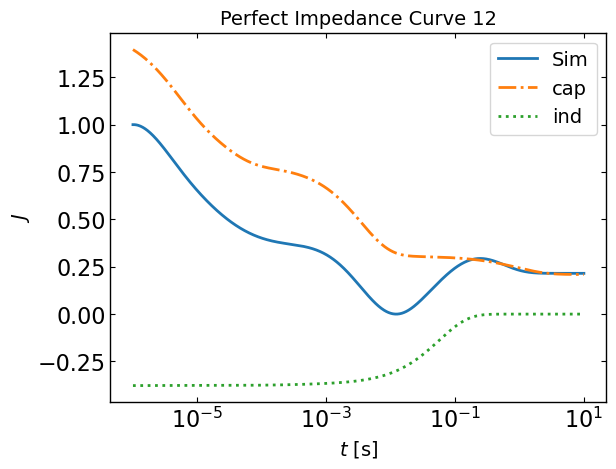

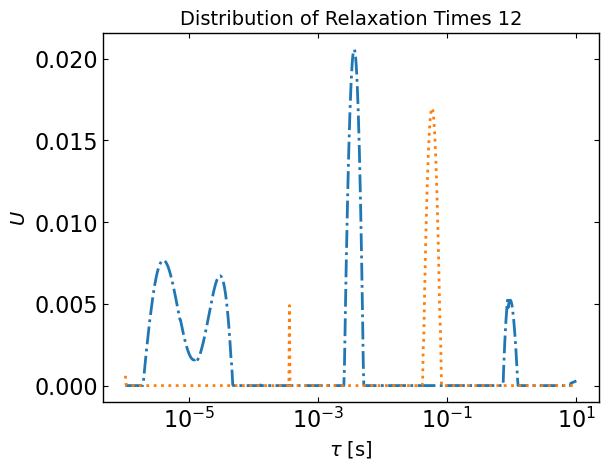

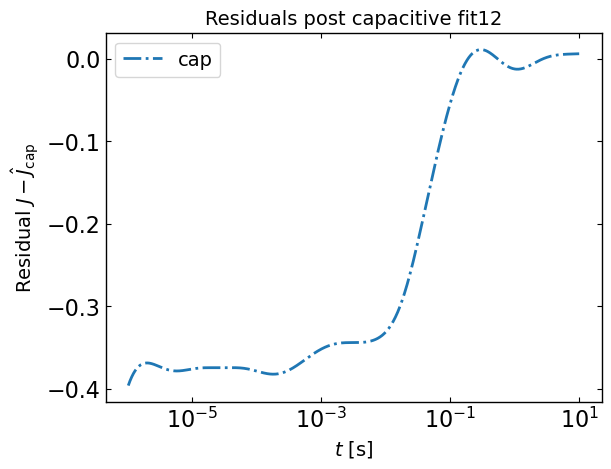

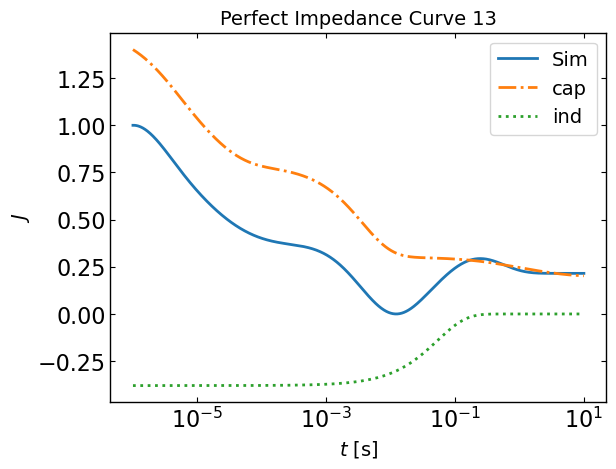

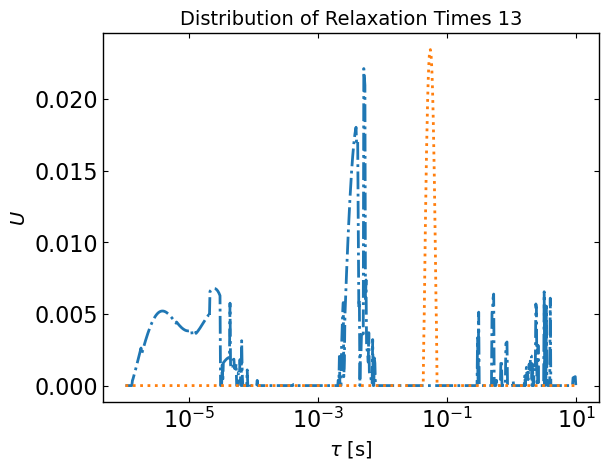

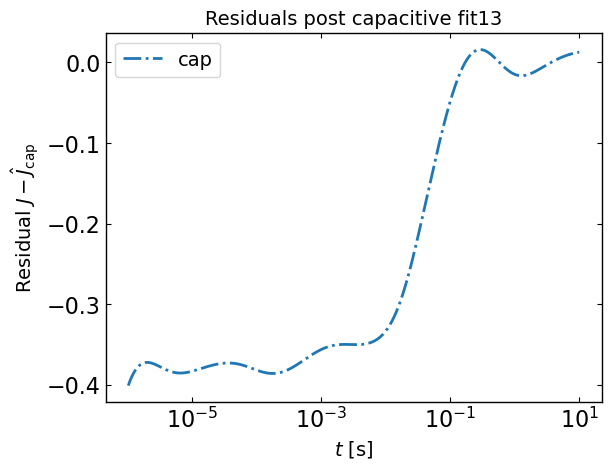

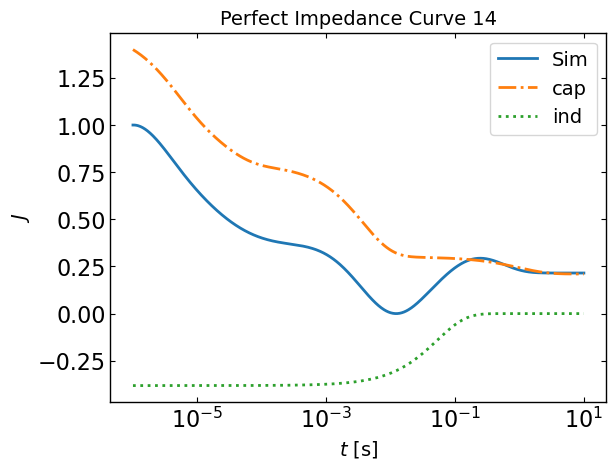

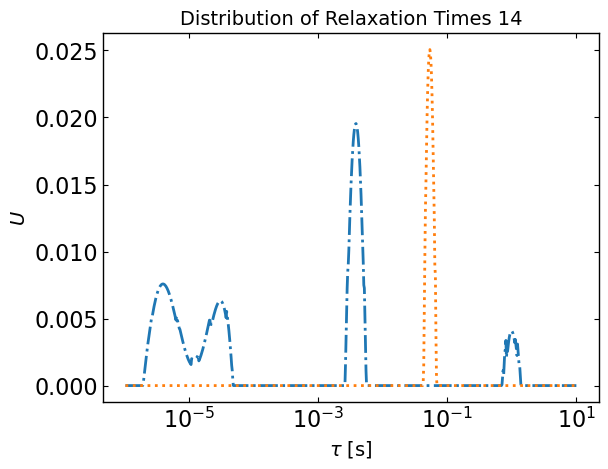

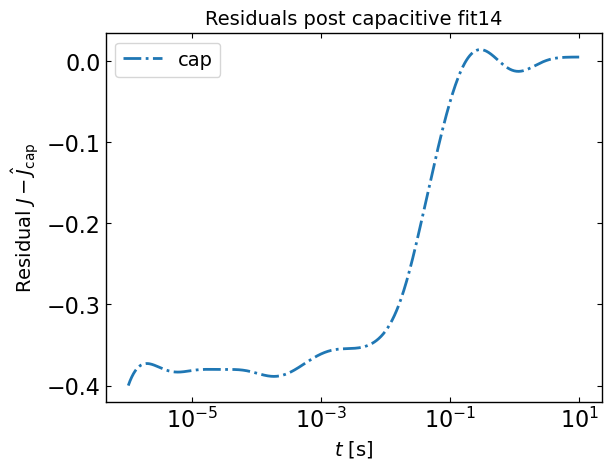

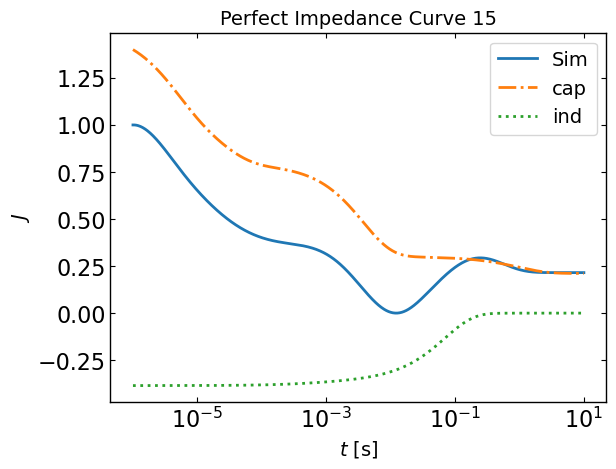

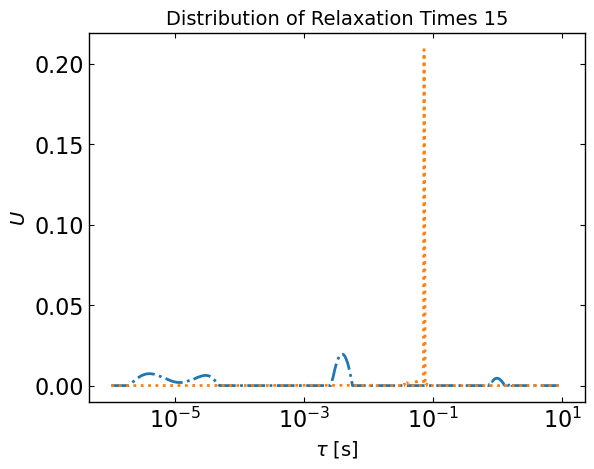

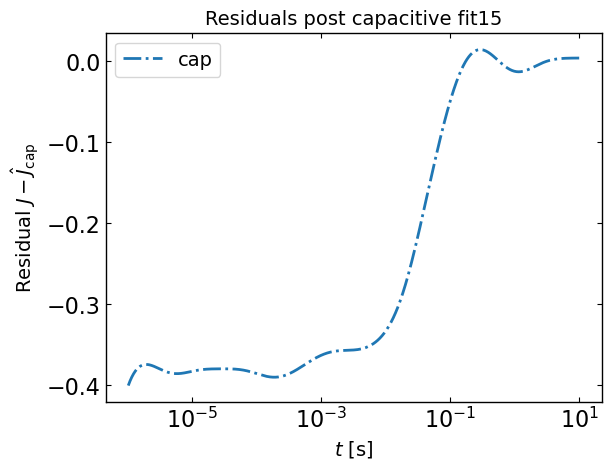

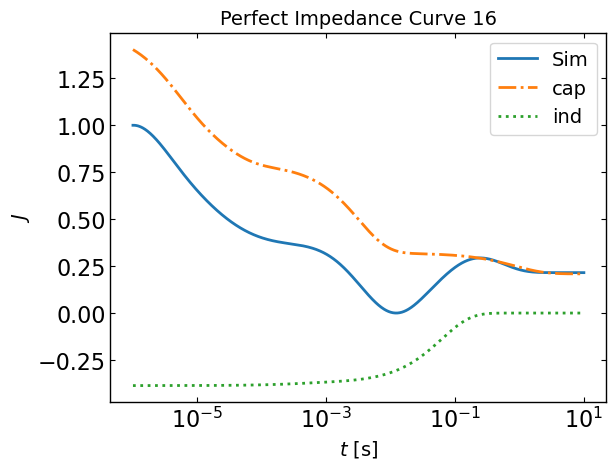

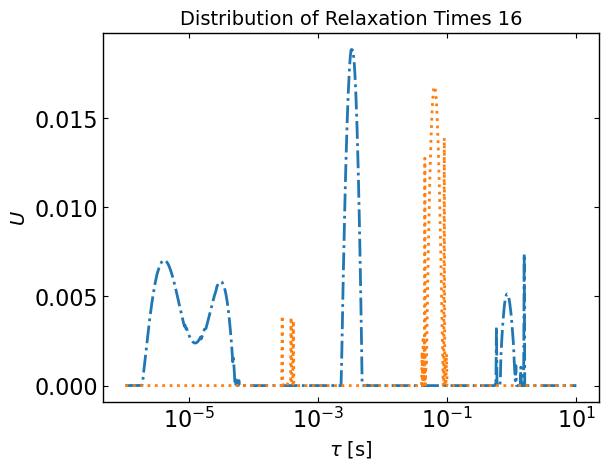

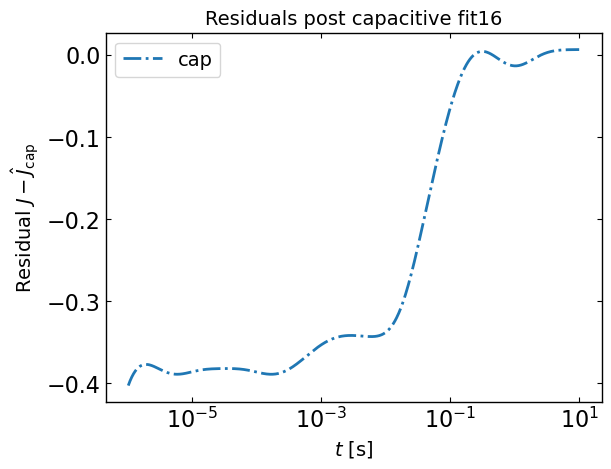

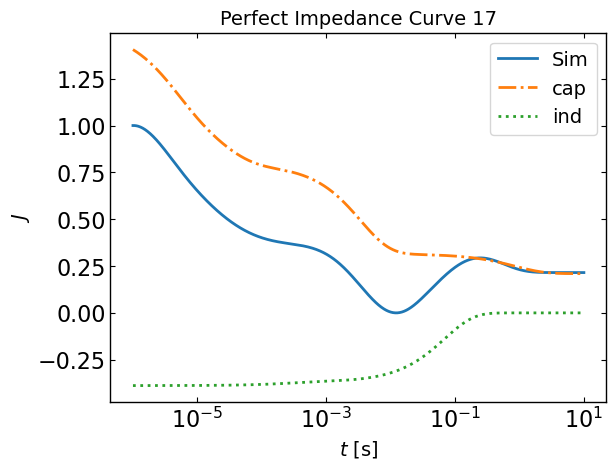

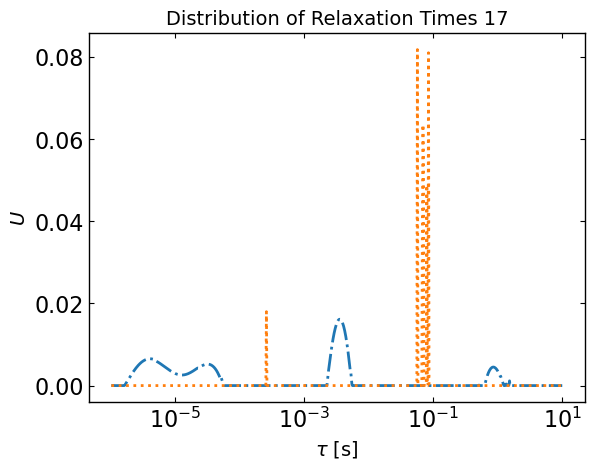

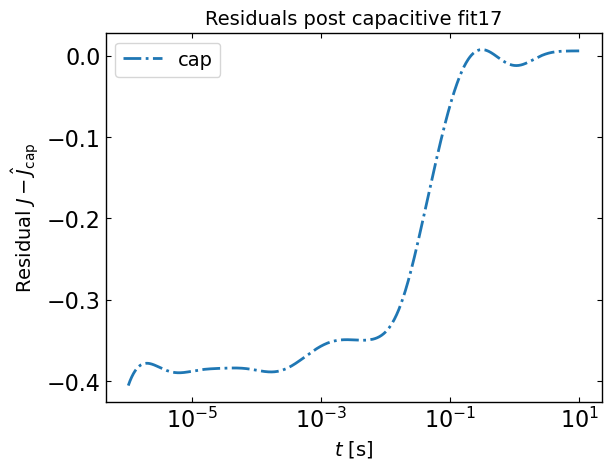

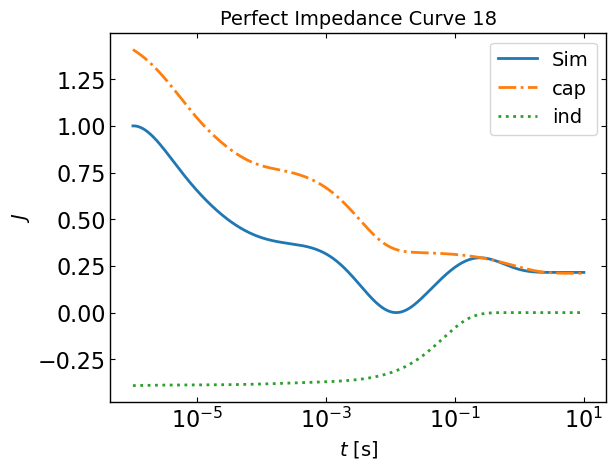

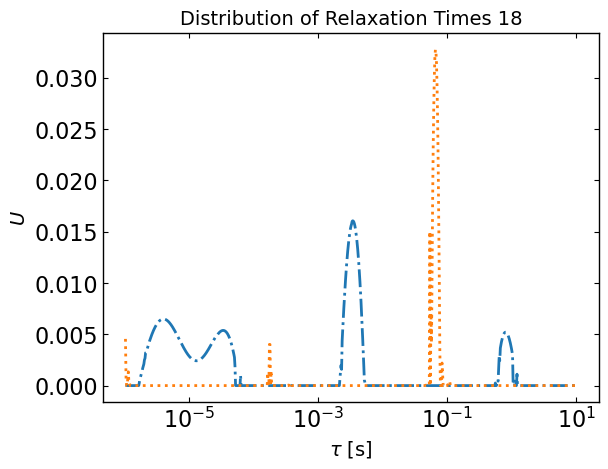

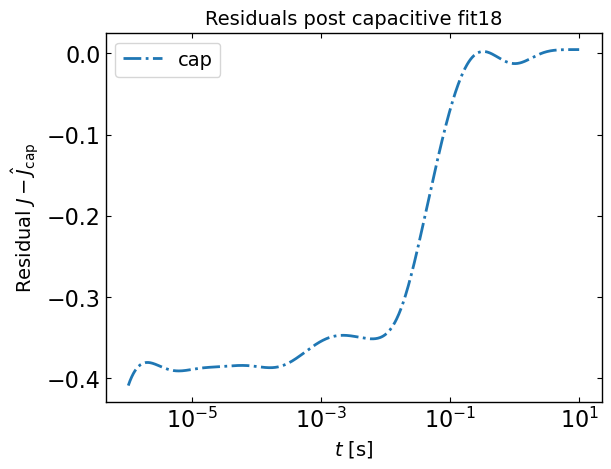

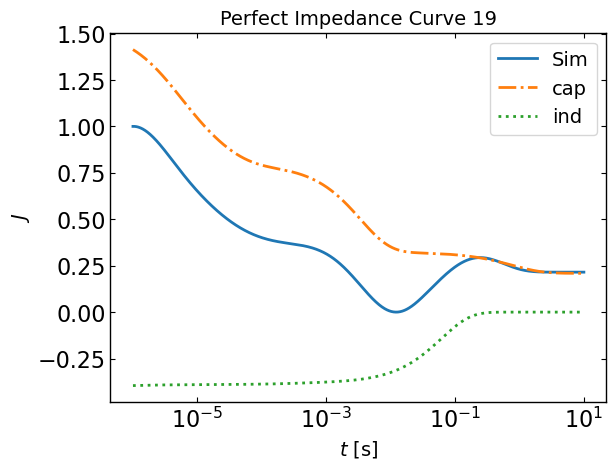

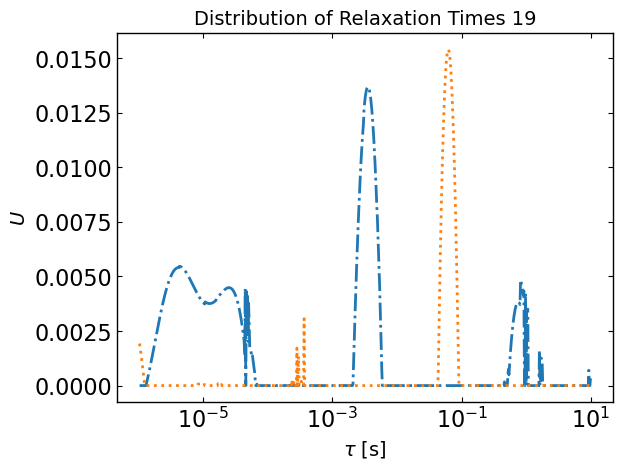

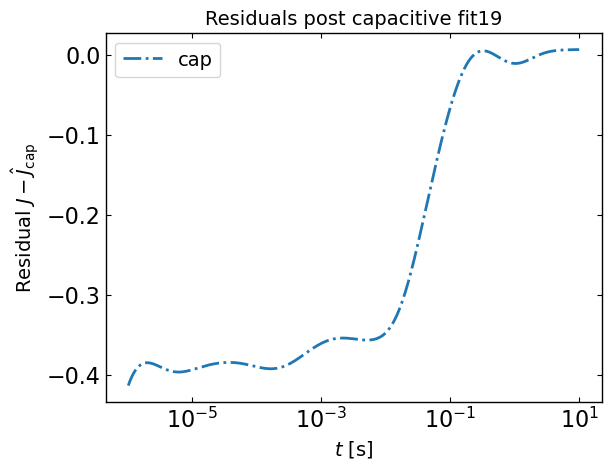

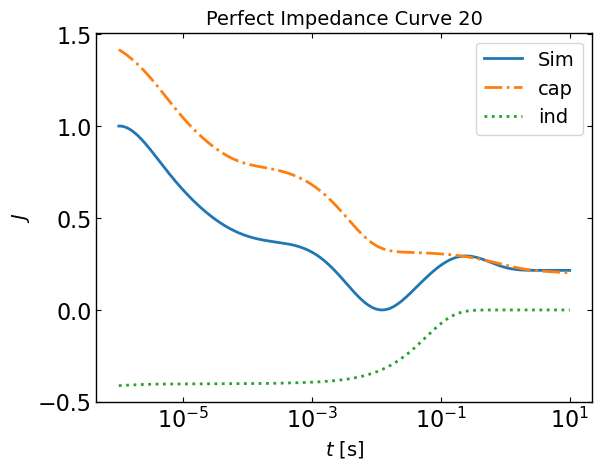

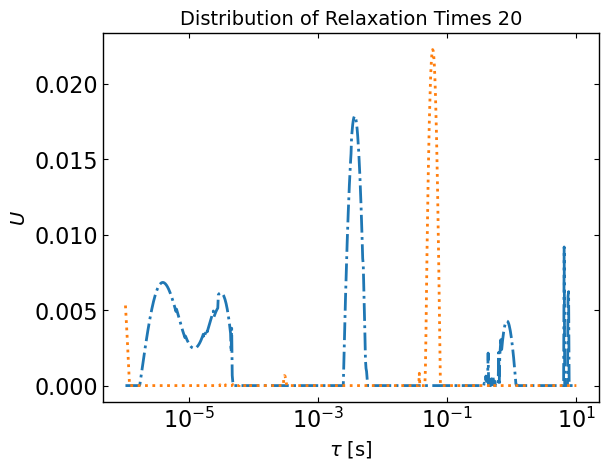

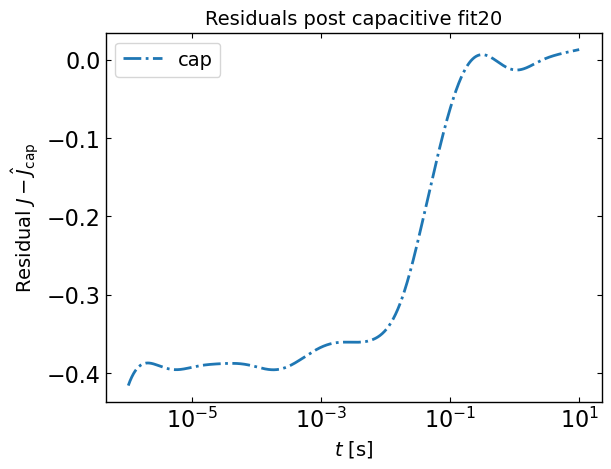

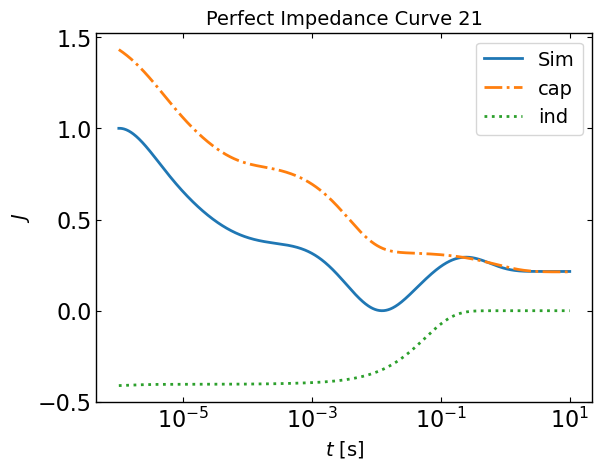

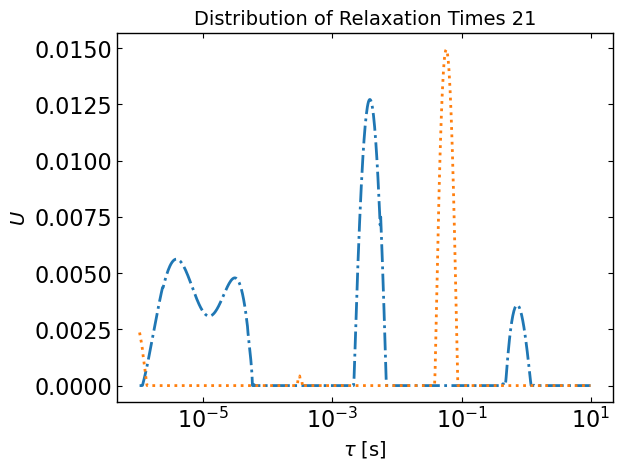

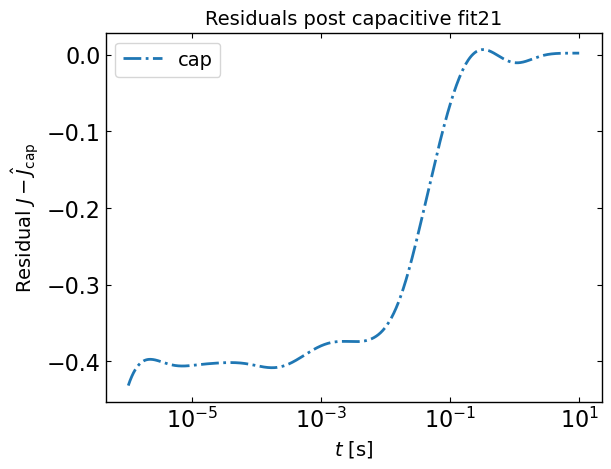

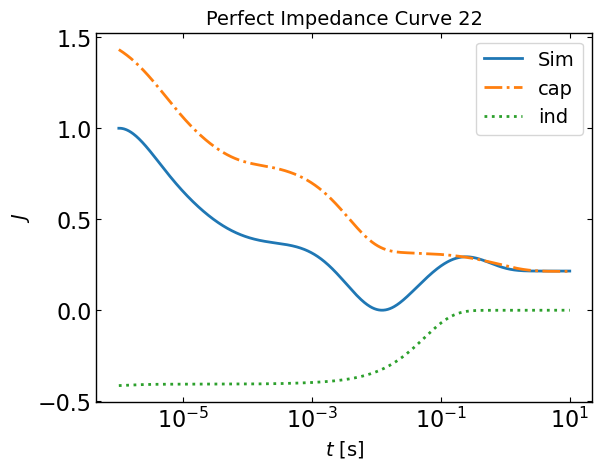

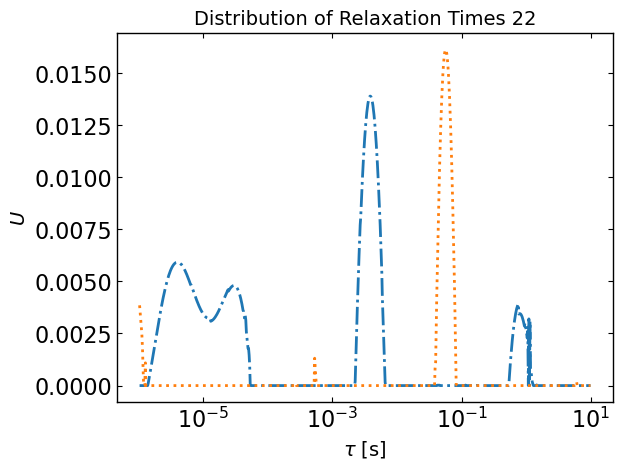

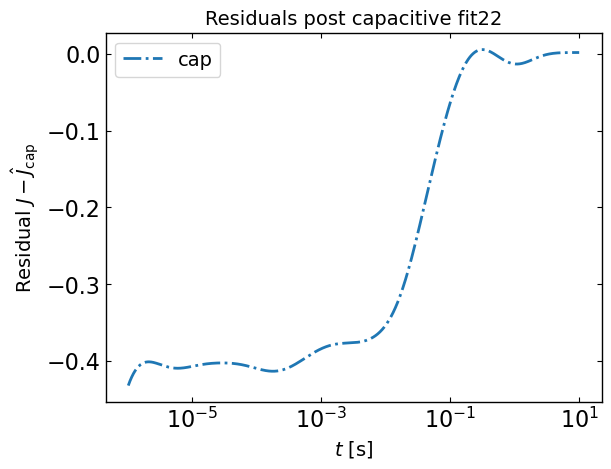

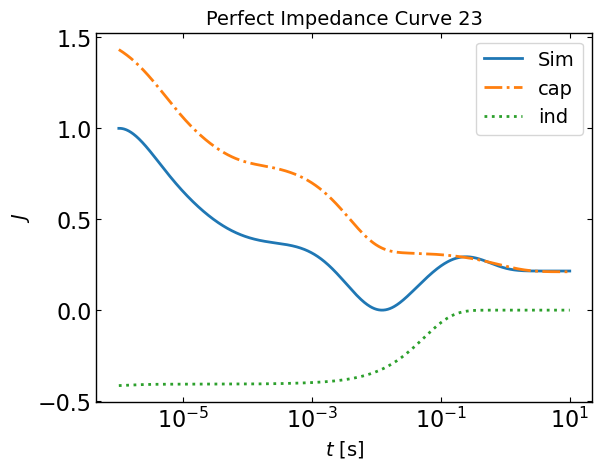

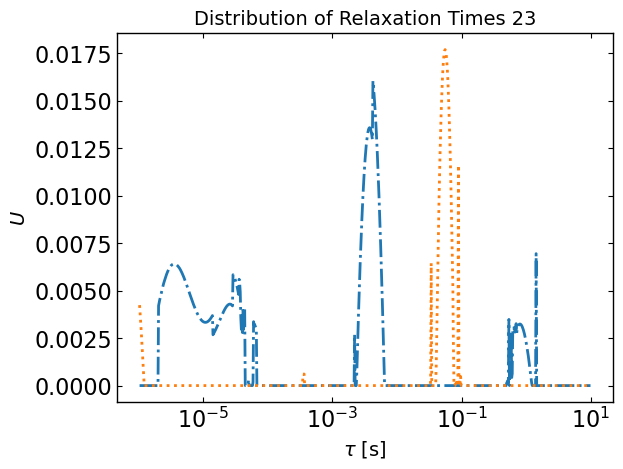

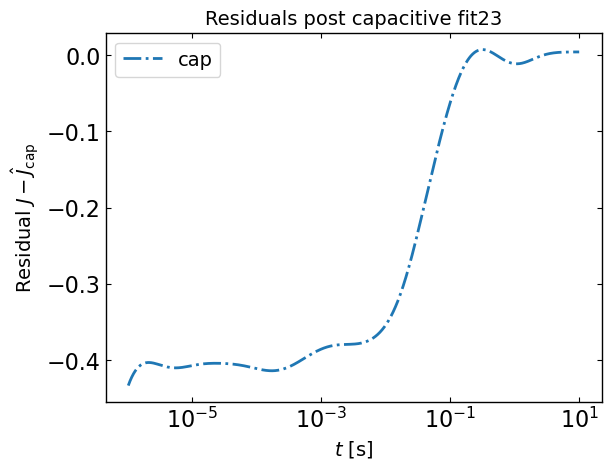

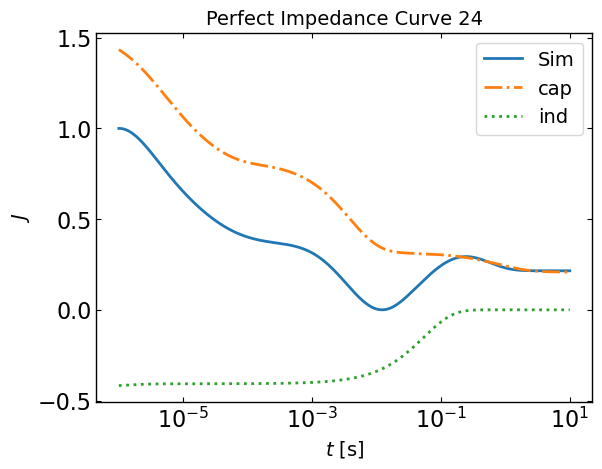

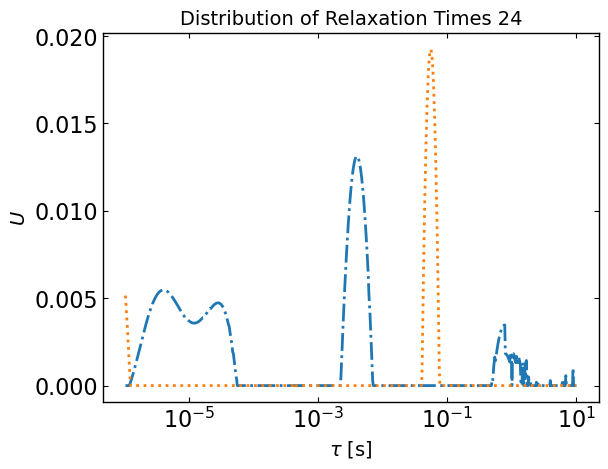

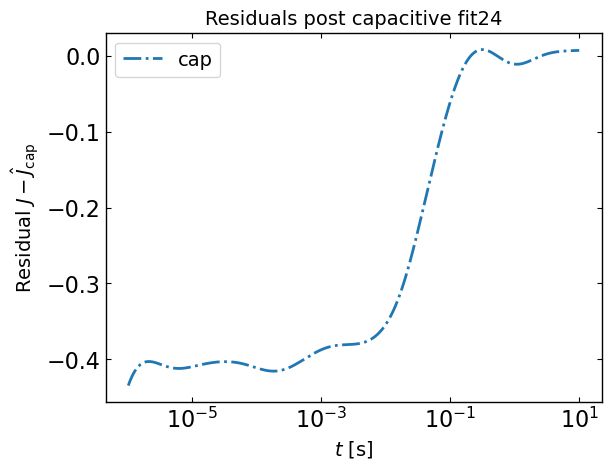

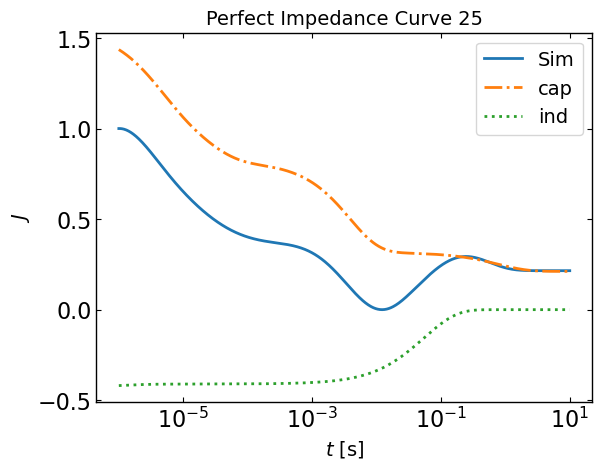

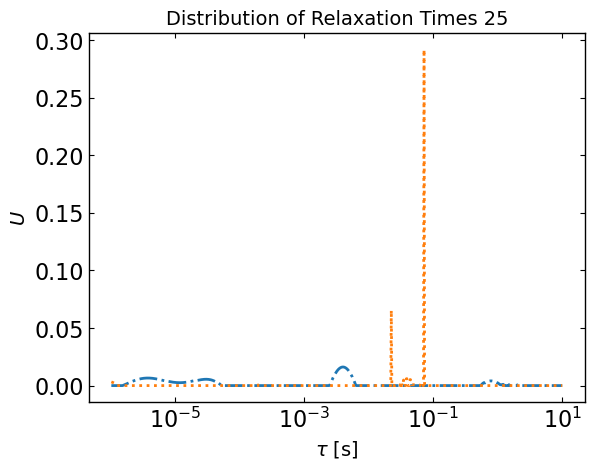

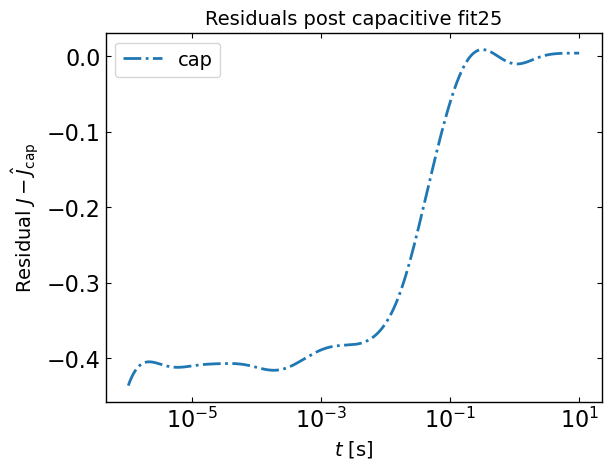

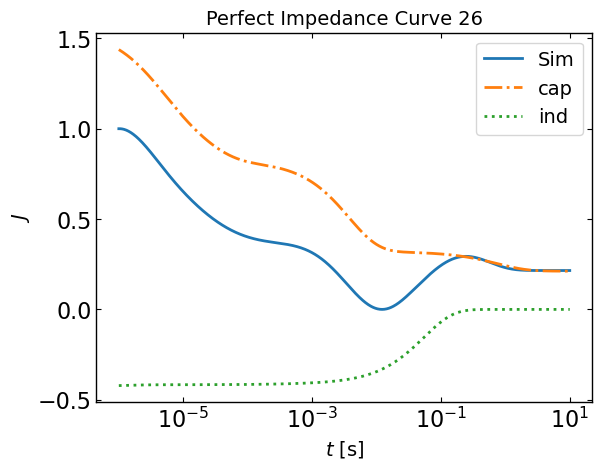

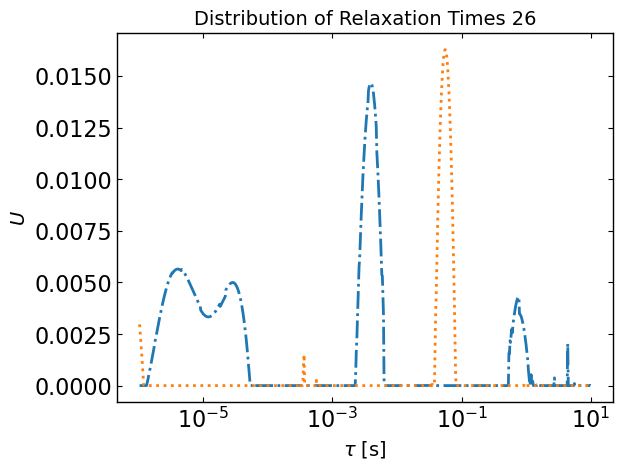

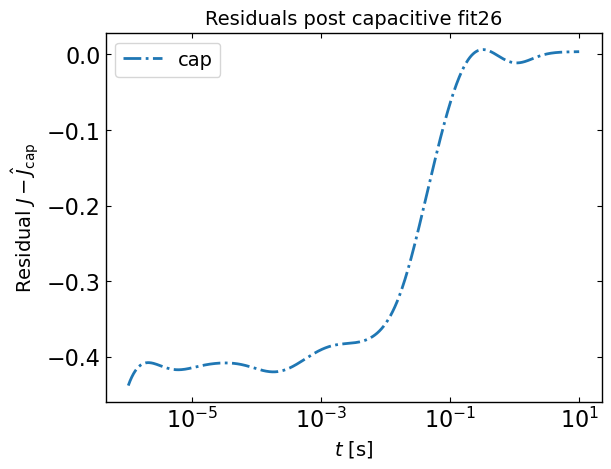

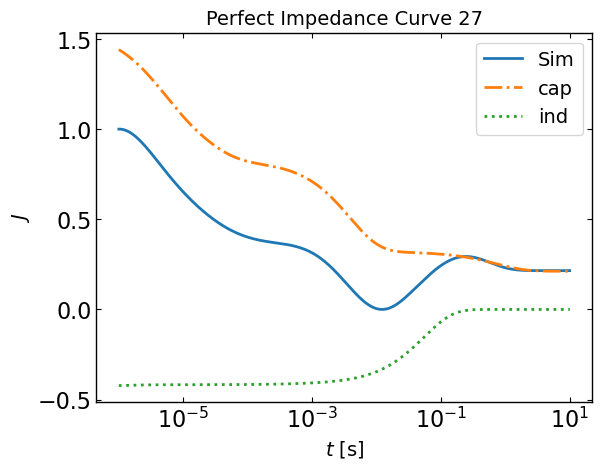

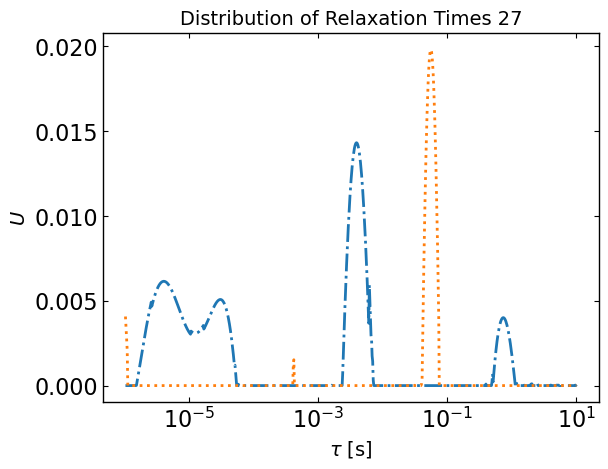

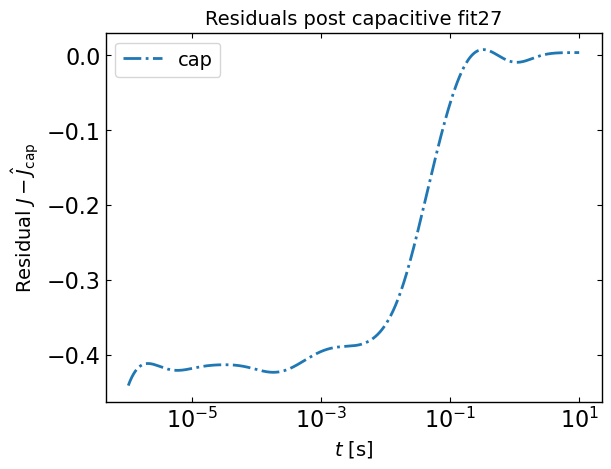

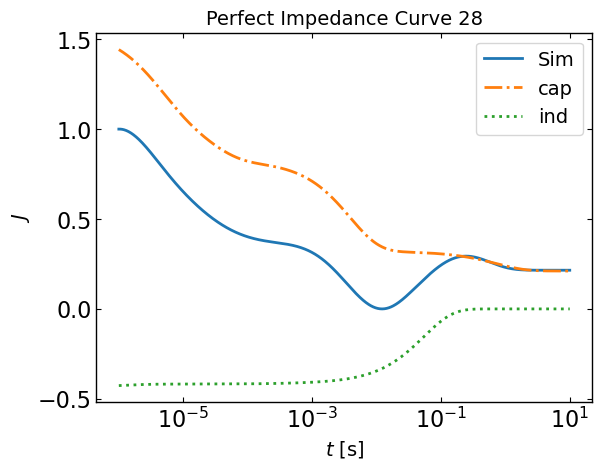

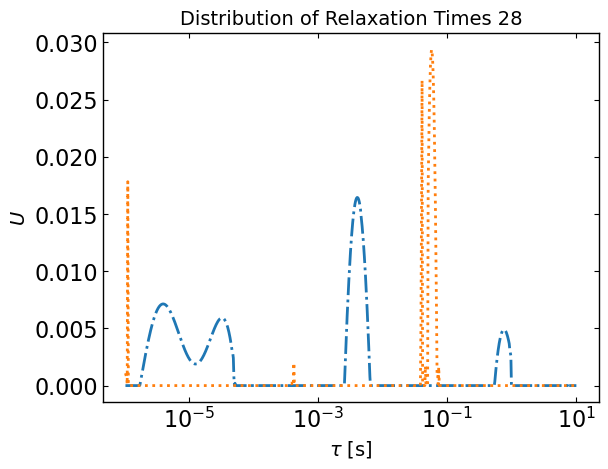

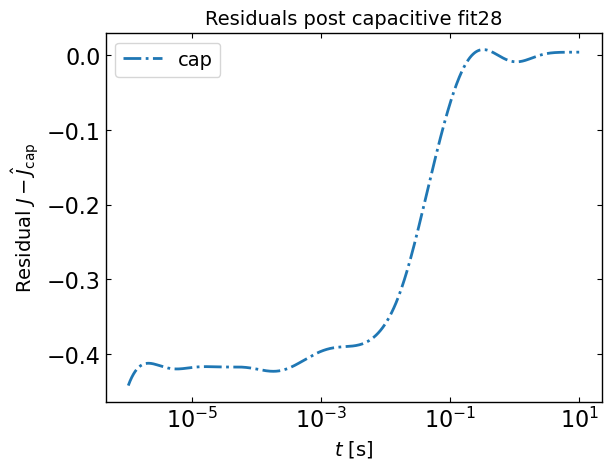

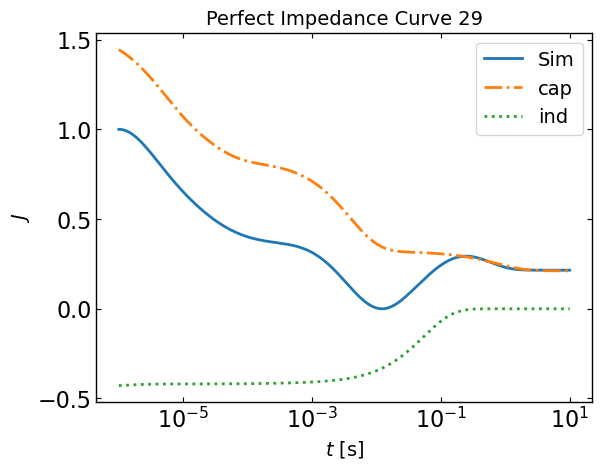

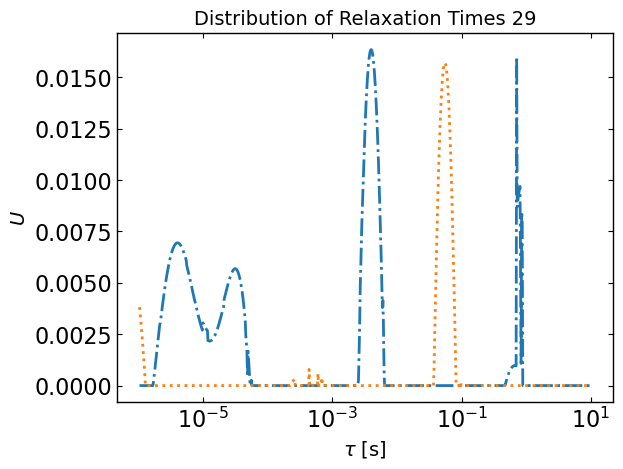

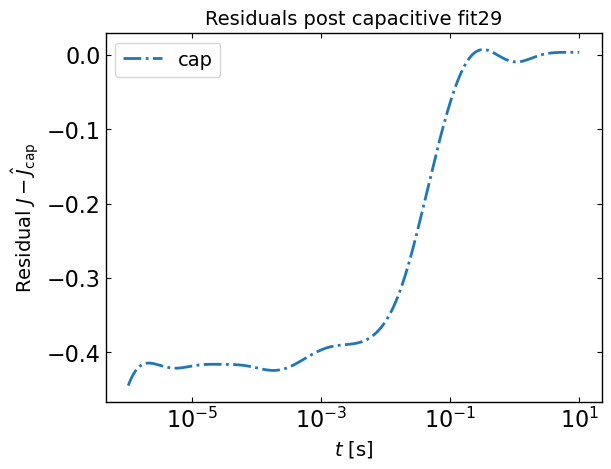

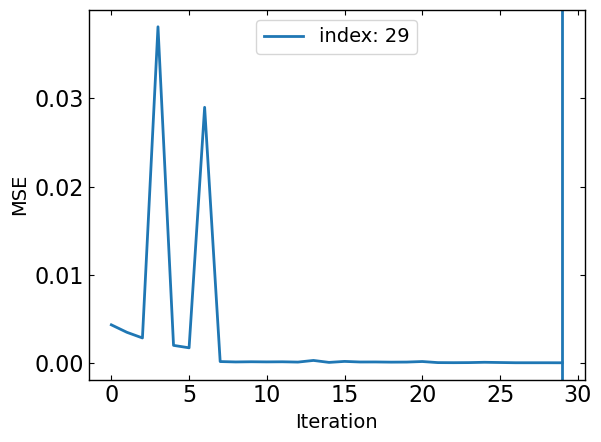

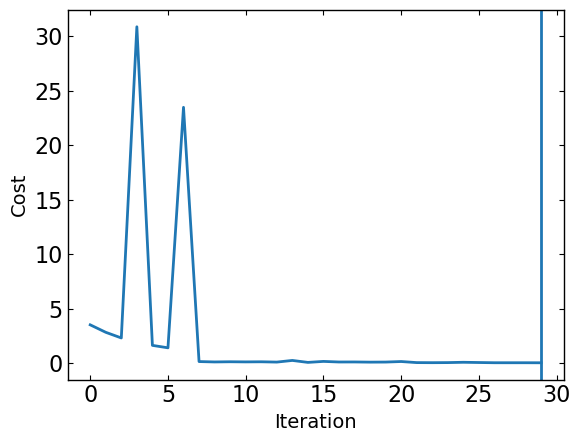

In [10]:
# Try the same again but with the checkerboard fit
checkerboard_fits = drt.fit_DRT_curve_checkerboard(time, current_scaled, time)

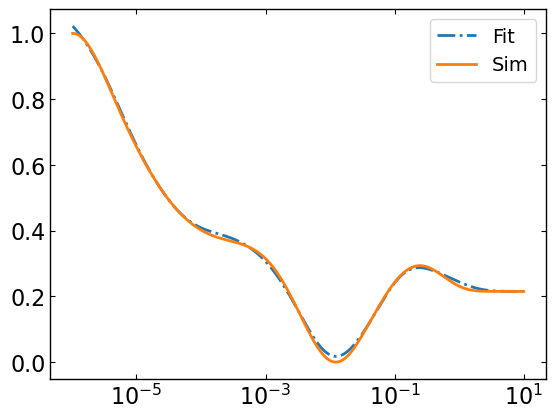

In [15]:
plt.plot(time, checkerboard_fits[27].DRT_curve, label='Fit', linestyle='-.')
plt.plot(time, current_scaled, label='Sim')
plt.xscale('log')
plt.legend()
plt.show()